In [15]:
# imports
from Bio import Entrez, SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

Entrez.email = "harshitpatel3358@gmail.com"
sns.set_style("whitegrid")
print("All imports done!")

All imports done!


In [16]:
# GC function
def calculate_gc(sequence):
    sequence = sequence.upper()
    gc = sequence.count('G') + sequence.count('C')
    total = len([b for b in sequence if b in 'ACGT'])
    return round((gc / total) * 100, 2) if total > 0 else 0

print("GC function ready!")

GC function ready!


In [17]:
# Fetch function
def fetch_phage_broad(host_name, search_name, max_records=40):
    search_term = f'bacteriophage[Title] AND "{search_name}"[Host]'
    handle = Entrez.esearch(db="nuccore", term=search_term, retmax=max_records)
    record = Entrez.read(handle)
    ids = record["IdList"]
    print(f"{host_name}: {len(ids)} IDs found, fetching...")
    
    genomes = []
    for uid in ids:
        try:
            fetch_handle = Entrez.efetch(db="nuccore", id=uid, rettype="gb", retmode="text")
            seq_record = SeqIO.read(fetch_handle, "genbank")
            if len(seq_record.seq) > 10000:
                gc = calculate_gc(str(seq_record.seq))
                genomes.append({
                    "accession": seq_record.id,
                    "host": host_name,
                    "genome_length": len(seq_record.seq),
                    "gc_content": gc,
                    "description": seq_record.description
                })
        except Exception as e:
            print(f"Skipped {uid}: {e}")
        time.sleep(0.4)
    
    print(f"{host_name}: {len(genomes)} valid genomes kept")
    return genomes

print("Fetch function ready!")

Fetch function ready!


In [18]:
# fetching the data
hosts = [
    ("Escherichia coli", "Escherichia coli"),
    ("Staphylococcus aureus", "Staphylococcus aureus"),
    ("Klebsiella", "Klebsiella pneumoniae"),
    ("Pseudomonas aeruginosa", "Pseudomonas aeruginosa"),
    ("Salmonella", "Salmonella enterica")
]

all_data = []
for host_name, search_name in hosts:
    data = fetch_phage_broad(host_name, search_name, max_records=40)
    all_data.extend(data)
    time.sleep(1)

df = pd.DataFrame(all_data)
df.to_csv("phage_genomes.csv", index=False)
print(f"\nTotal records: {len(df)}")
print(df.groupby("host")["accession"].count())

Escherichia coli: 40 IDs found, fetching...
Escherichia coli: 23 valid genomes kept
Staphylococcus aureus: 40 IDs found, fetching...
Staphylococcus aureus: 6 valid genomes kept
Klebsiella: 24 IDs found, fetching...
Klebsiella: 11 valid genomes kept
Pseudomonas aeruginosa: 40 IDs found, fetching...
Pseudomonas aeruginosa: 34 valid genomes kept
Salmonella: 40 IDs found, fetching...
Salmonella: 7 valid genomes kept

Total records: 81
host
Escherichia coli          23
Klebsiella                11
Pseudomonas aeruginosa    34
Salmonella                 7
Staphylococcus aureus      6
Name: accession, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1528\598209908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="host", y="genome_length", palette="Set2")


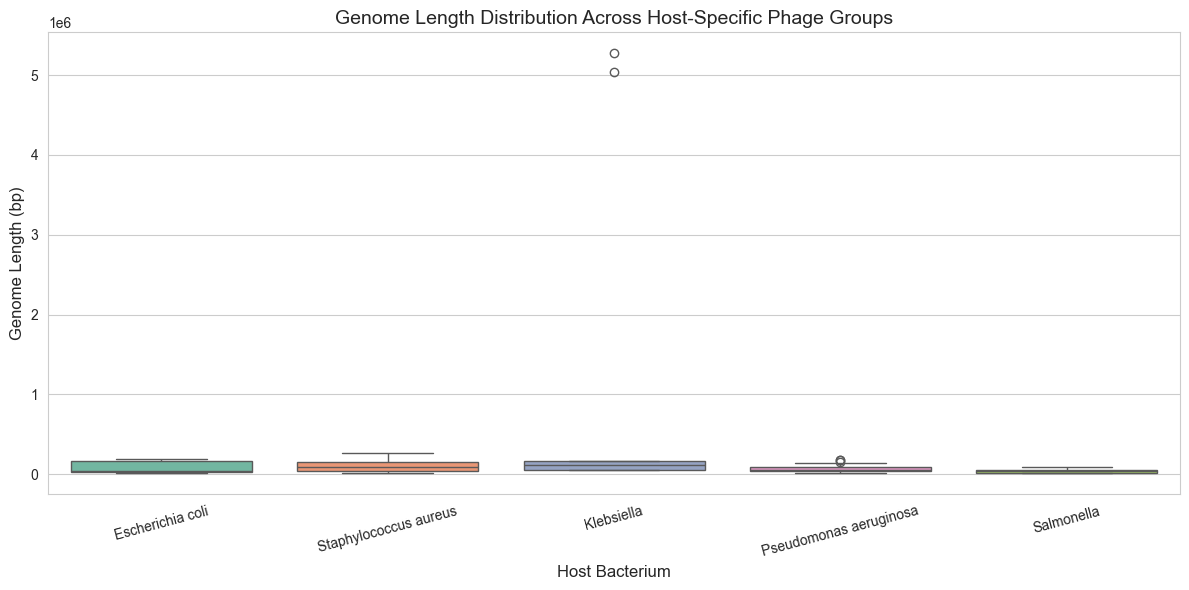

Plot 1 done!


In [ ]:
# Plot 1: Genome Length
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="host", y="genome_length", palette="Set2")
plt.xticks(rotation=15)
plt.title("Genome Length Distribution Across Host-Specific Phage Groups", fontsize=14)
plt.xlabel("Host Bacterium", fontsize=12)
plt.ylabel("Genome Length (bp)", fontsize=12)
plt.tight_layout()
plt.savefig("genome_length_distribution.png", dpi=150)
plt.show()
print("Plot 1 done!")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1528\3795971102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="host", y="gc_content", palette="Set3", inner="quartile")


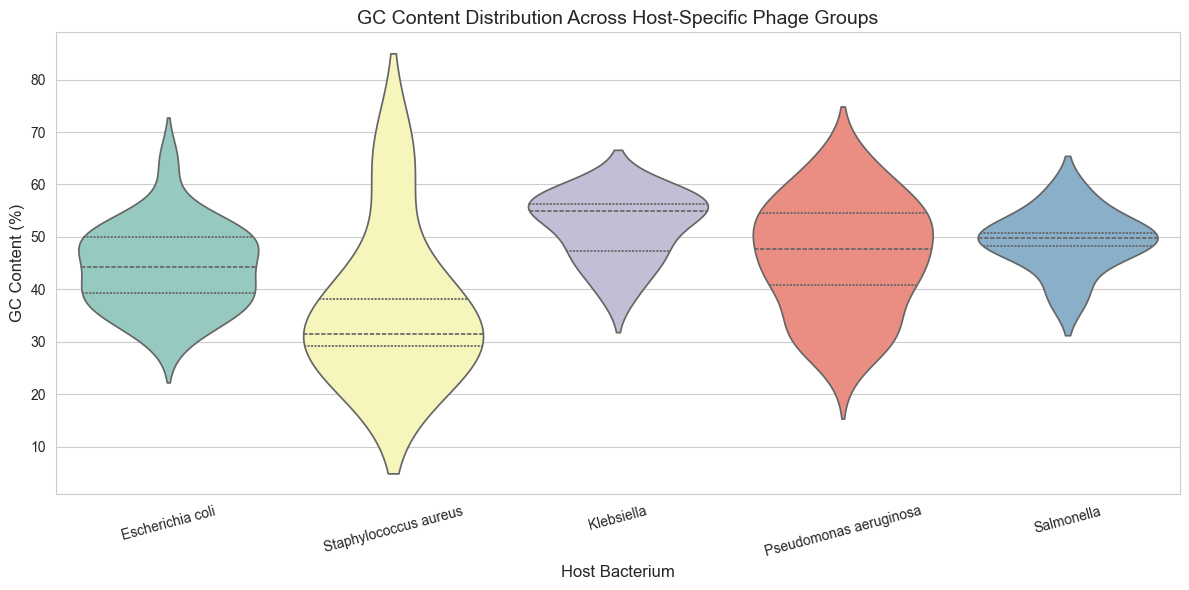

Plot 2 done!


In [20]:
# Plot 2: GC Content
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="host", y="gc_content", palette="Set3", inner="quartile")
plt.xticks(rotation=15)
plt.title("GC Content Distribution Across Host-Specific Phage Groups", fontsize=14)
plt.xlabel("Host Bacterium", fontsize=12)
plt.ylabel("GC Content (%)", fontsize=12)
plt.tight_layout()
plt.savefig("gc_content_distribution.png", dpi=150)
plt.show()
print("Plot 2 done!")

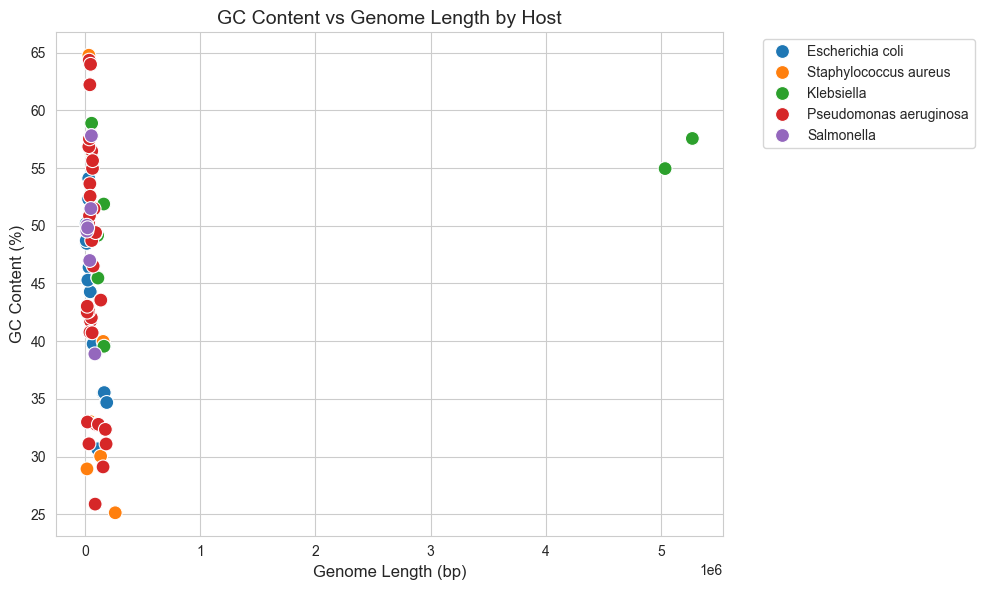

Plot 3 done!


In [21]:
# Plot 3: GC vs Genome Length
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="genome_length", y="gc_content", hue="host", palette="tab10", s=100)
plt.title("GC Content vs Genome Length by Host", fontsize=14)
plt.xlabel("Genome Length (bp)", fontsize=12)
plt.ylabel("GC Content (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("gc_vs_length_scatter.png", dpi=150)
plt.show()
print("Plot 3 done!")

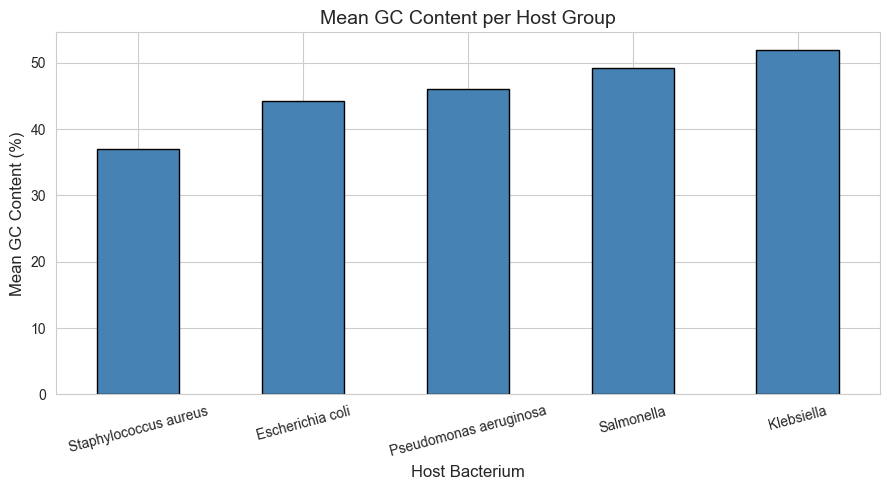

Plot 4 done!


In [22]:
 # Plot 4: Mean GC per Host
mean_gc = df.groupby("host")["gc_content"].mean().sort_values()

plt.figure(figsize=(9, 5))
mean_gc.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Mean GC Content per Host Group", fontsize=14)
plt.ylabel("Mean GC Content (%)", fontsize=12)
plt.xlabel("Host Bacterium", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("mean_gc_per_host.png", dpi=150)
plt.show()
print("Plot 4 done!")

In [23]:
# Summary
summary = df.groupby("host").agg(
    count=("accession", "count"),
    mean_genome_length=("genome_length", "mean"),
    std_genome_length=("genome_length", "std"),
    mean_gc=("gc_content", "mean"),
    std_gc=("gc_content", "std")
).round(2)

print(summary)

                        count  mean_genome_length  std_genome_length  mean_gc  \
host                                                                            
Escherichia coli           23            84278.39           64845.98    44.29   
Klebsiella                 11          1018965.09         2045779.04    51.99   
Pseudomonas aeruginosa     34            67830.53           42957.18    46.11   
Salmonella                  7            42150.71           25187.59    49.23   
Staphylococcus aureus       6           109057.67           94970.05    36.99   

                        std_gc  
host                            
Escherichia coli          7.90  
Klebsiella                6.24  
Pseudomonas aeruginosa   10.68  
Salmonella                5.65  
Staphylococcus aureus    14.49  
